# About Dataset

link  https://www.kaggle.com/datasets/subirbiswas19/skin-disease-dataset/data


Some types of pathogens — notably bacteria and fungi — are typically present on the skin, but if they become too numerous, the immune system can no longer manage them.In this case, an infection can resul

## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

## Load The Data

In [3]:
train_dir = '/kaggle/input/skin-disease-dataset/skin-disease-datasaet/train_set'
test_dir = '/kaggle/input/skin-disease-dataset/skin-disease-datasaet/test_set'

## ImageDataGenerator

In [5]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32



train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [6]:
train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)

test_gen = test_datagen.flow_from_directory(
    test_dir, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

Found 924 images belonging to 8 classes.
Found 233 images belonging to 8 classes.


## Contrast Limited Adaptive Histogram Equalization

In [7]:
'''CLAHE = Contrast Limited Adaptive Histogram Equalization It improves local contrast — unlike standard histogram equalization which works globally, CLAHE works on small tiles (regions), then combines them smoothly.

✅ Helps highlight details in dark or bright regions.

✅ Reduces over-amplification of noise compared to normal AHE.'''

def apply_clahe(image):
    # Konversi float -> uint8 (jika perlu)
    if image.dtype != np.uint8:
        image = np.clip(image, 0, 255).astype(np.uint8)
    
    # Pastikan gambar punya 3 channel
    if len(image.shape) == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    
    # Ubah ke grayscale
    img_gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    # Terapkan CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_gray)
    
    # Kembalikan ke RGB (3 channel)
    img_clahe = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2RGB)
    
    return img_clahe

## ImageDataGenerator (Training, Validation, Testing)

In [8]:
train_datagen = ImageDataGenerator(

    preprocessing_function=lambda img: preprocess_input(apply_clahe(img)),
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=lambda img: preprocess_input(apply_clahe(img))
)

## Load Dataset

In [9]:
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb'
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)

Found 924 images belonging to 8 classes.
Found 233 images belonging to 8 classes.


## Hitung Class Weight (imbalance data)

In [11]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: 0.8555555555555555, 1: 1.44375, 2: 0.9314516129032258, 3: 0.8953488372093024, 4: 1.2833333333333334, 5: 1.155, 6: 0.8492647058823529, 7: 0.8884615384615384}


##  ResNet50 Model

In [13]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(8, activation='softmax')(x)   # 8 classes → softmax

# Build the final model
model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',          # for multi-class
    metrics=['accuracy']
)

# Show model summary
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,851,016 (90.98 MB)

 Trainable params: 263,304 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Callback: EarlyStopping & ModelCheckpoint

In [16]:
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=20,
    class_weight=class_weights,
    callbacks=[checkpoint, earlystop]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1762499821.461320     142 service.cc:148] XLA service 0x7992c4014b40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762499821.462371     142 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1762499823.080724     142 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/29 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.1016 - loss: 3.8666 

I0000 00:00:1762499827.913627     142 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 484ms/step - accuracy: 0.6943 - loss: 0.9370 - val_accuracy: 0.8455 - val_loss: 0.5504
Epoch 16/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.6881 - loss: 0.8881
Epoch 16: val_accuracy improved from 0.84549 to 0.85837, saving model to best_model.h5


29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 480ms/step - accuracy: 0.6872 - loss: 0.8897 - val_accuracy: 0.8584 - val_loss: 0.5161
Epoch 17/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.6915 - loss: 0.8682
Epoch 17: val_accuracy did not improve from 0.85837
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 459ms/step - accuracy: 0.6913 - loss: 0.8679 - val_accuracy: 0.8498 - val_loss: 0.5006
Epoch 18/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.7205 - loss: 0.8008
Epoch 18: val_accuracy improved from 0.85837 to 0.86266, saving model to best_model.h5


29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 487ms/step - accuracy: 0.7202 - loss: 0.8014 - val_accuracy: 0.8627 - val_loss: 0.4782
Epoch 19/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.7100 - loss: 0.8431
Epoch 19: val_accuracy improved from 0.86266 to 0.87124, saving model to best_model.h5


29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 468ms/step - accuracy: 0.7103 - loss: 0.8418 - val_accuracy: 0.8712 - val_loss: 0.4554
Epoch 20/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.6927 - loss: 0.8556
Epoch 20: val_accuracy improved from 0.87124 to 0.88412, saving model to best_model.h5


29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 478ms/step - accuracy: 0.6940 - loss: 0.8540 - val_accuracy: 0.8841 - val_loss: 0.4378


## Fine Tune

In [18]:
for layer in base_model.layers[-30:]:  # unfreeze last 30 layers (tweak as needed)
    layer.trainable = True

# Compile again with a smaller learning rate
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # smaller LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tune model
history_finetune = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=10,
    class_weight=class_weights,
    callbacks=[checkpoint, earlystop]
)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.6860 - loss: 0.9556
Epoch 1: val_accuracy improved from 0.88412 to 0.89270, saving model to best_model.h5


29/29 ━━━━━━━━━━━━━━━━━━━━ 44s 901ms/step - accuracy: 0.6860 - loss: 0.9548 - val_accuracy: 0.8927 - val_loss: 0.4128
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.7151 - loss: 0.8433
Epoch 2: val_accuracy improved from 0.89270 to 0.91416, saving model to best_model.h5


29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 483ms/step - accuracy: 0.7154 - loss: 0.8423 - val_accuracy: 0.9142 - val_loss: 0.3935
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.7386 - loss: 0.7804
Epoch 3: val_accuracy improved from 0.91416 to 0.91845, saving model to best_model.h5


29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 481ms/step - accuracy: 0.7392 - loss: 0.7792 - val_accuracy: 0.9185 - val_loss: 0.3773
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.7859 - loss: 0.6638
Epoch 4: val_accuracy improved from 0.91845 to 0.92704, saving model to best_model.h5


29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 491ms/step - accuracy: 0.7853 - loss: 0.6650 - val_accuracy: 0.9270 - val_loss: 0.3613
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.7806 - loss: 0.6512
Epoch 5: val_accuracy did not improve from 0.92704
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 450ms/step - accuracy: 0.7812 - loss: 0.6502 - val_accuracy: 0.9270 - val_loss: 0.3433
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.7993 - loss: 0.5827
Epoch 6: val_accuracy improved from 0.92704 to 0.93133, saving model to best_model.h5


29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 475ms/step - accuracy: 0.7995 - loss: 0.5826 - val_accuracy: 0.9313 - val_loss: 0.3290
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.8179 - loss: 0.5207
Epoch 7: val_accuracy improved from 0.93133 to 0.93562, saving model to best_model.h5


29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 473ms/step - accuracy: 0.8184 - loss: 0.5207 - val_accuracy: 0.9356 - val_loss: 0.3127
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.8374 - loss: 0.5319
Epoch 8: val_accuracy did not improve from 0.93562
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 451ms/step - accuracy: 0.8374 - loss: 0.5307 - val_accuracy: 0.9313 - val_loss: 0.2997
Epoch 9/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.8668 - loss: 0.4473
Epoch 9: val_accuracy improved from 0.93562 to 0.94421, saving model to best_model.h5


29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 485ms/step - accuracy: 0.8664 - loss: 0.4484 - val_accuracy: 0.9442 - val_loss: 0.2861
Epoch 10/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.8587 - loss: 0.4796
Epoch 10: val_accuracy did not improve from 0.94421
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 452ms/step - accuracy: 0.8593 - loss: 0.4779 - val_accuracy: 0.9442 - val_loss: 0.2718


## Evaluate

In [19]:
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.9350 - loss: 0.2879
Test Accuracy: 0.9442


## Classification Report

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step

Classification Report:
                            precision    recall  f1-score   support

            BA- cellulitis       0.94      0.91      0.92        33
               BA-impetigo       0.95      1.00      0.98        20
           FU-athlete-foot       0.97      0.88      0.92        32
            FU-nail-fungus       0.94      1.00      0.97        33
               FU-ringworm       1.00      0.91      0.95        23
PA-cutaneous-larva-migrans       0.81      0.88      0.85        25
             VI-chickenpox       1.00      1.00      1.00        34
               VI-shingles       0.94      0.97      0.96        33

                  accuracy                           0.94       233
                 macro avg       0.94      0.94      0.94       233
              weighted avg       0.95      0.94      0.94       233



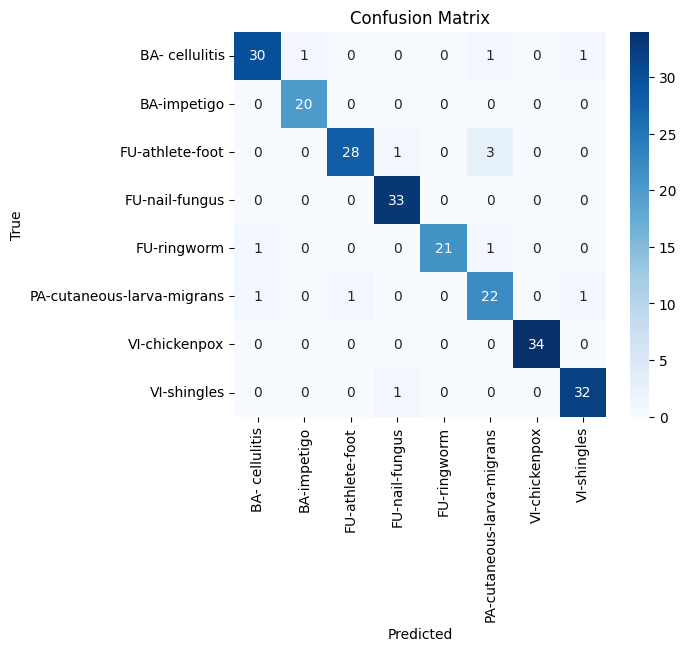

In [21]:
# Predict class probabilities
y_pred_probs = model.predict(test_gen)

# Convert probabilities to class indices
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

# Class labels
class_labels = list(test_gen.class_indices.keys())

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
